<a href="https://colab.research.google.com/github/SKSAHILAKHTAR1/AI-Powered-SDR-Laboratory/blob/main/Line%20coding%20and%20PSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

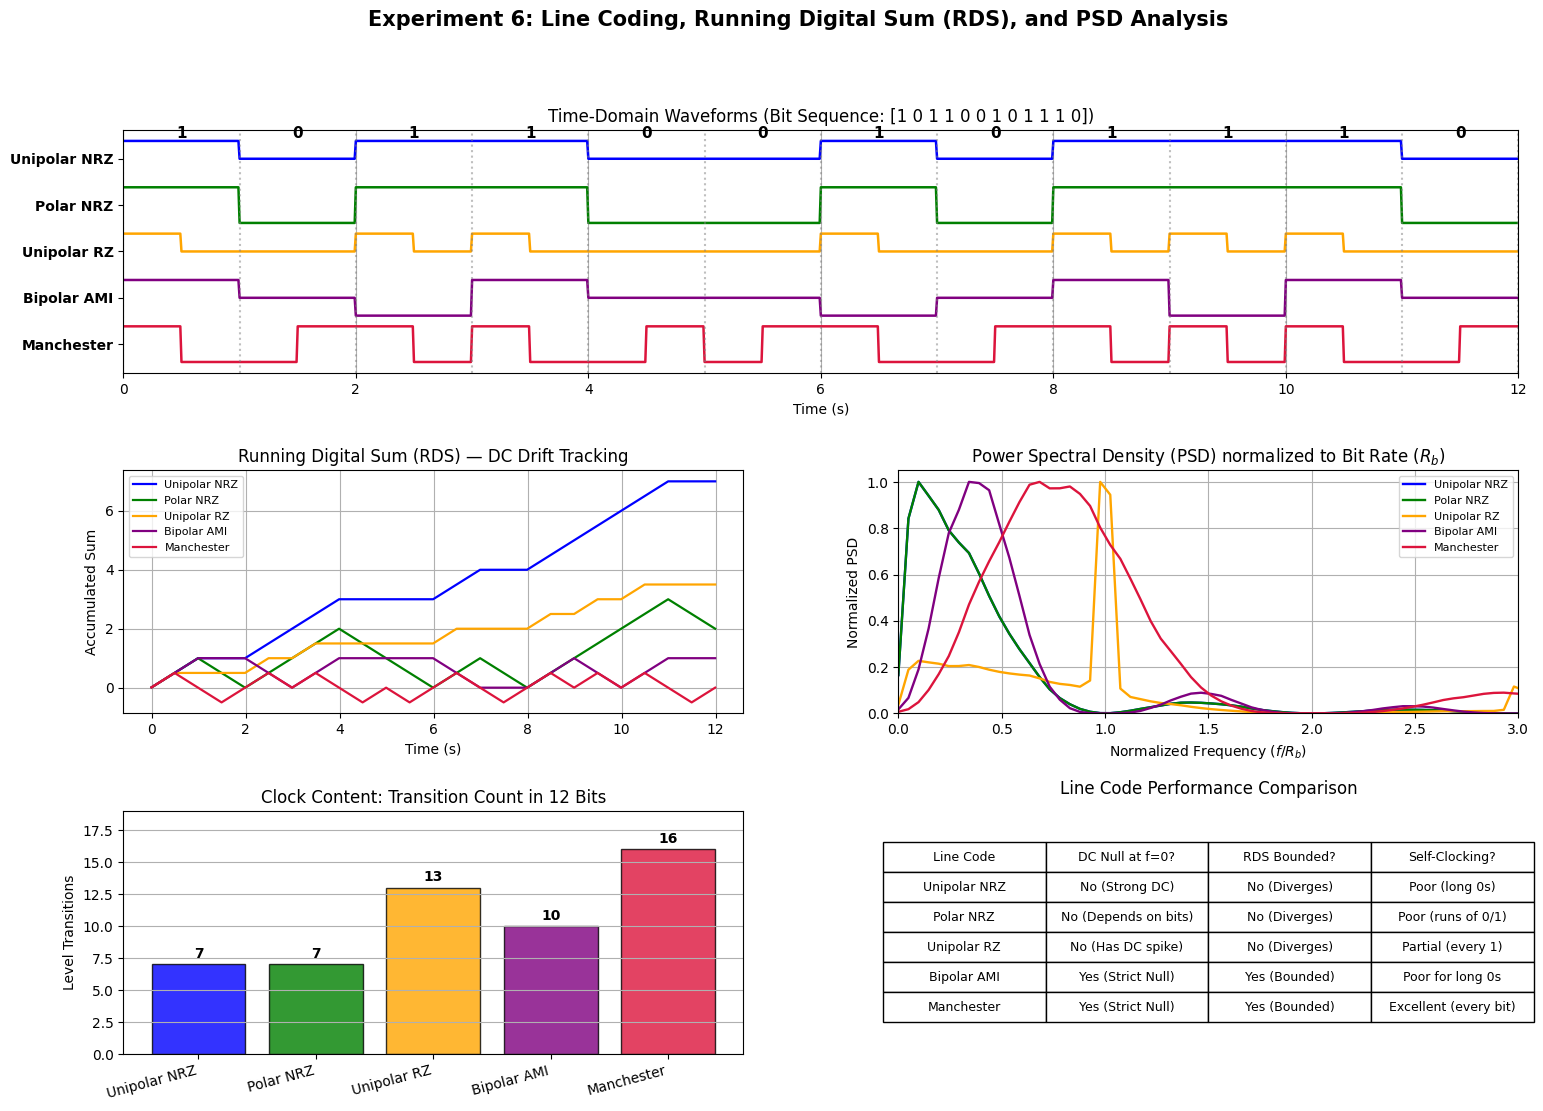

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ====================================================================
# 1. PARAMETERS & BIT GENERATION
# ====================================================================
np.random.seed(42)                  # Reproducibility
N_bits_display = 12                 # Short bitstream for time-domain visual display
bits_display = np.array([1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0])

N_bits_psd = 10000                  # Large random bit sequence for accurate PSD estimation
bits_psd = np.random.randint(0, 2, N_bits_psd)

samples_per_bit = 100               # Oversampling factor per bit
Tb = 1.0                            # Bit duration (seconds) -> Rb = 1 bps
fs = samples_per_bit / Tb           # Sampling frequency (100 Hz)

# ====================================================================
# 2. LINE CODING GENERATORS
# ====================================================================
def generate_line_codes(bits, spb):
    N = len(bits)
    total_samples = N * spb

    # Preallocate waveforms
    unipolar_nrz = np.zeros(total_samples)
    polar_nrz = np.zeros(total_samples)
    unipolar_rz = np.zeros(total_samples)
    bipolar_ami = np.zeros(total_samples)
    manchester = np.zeros(total_samples)

    half_spb = spb // 2
    last_ami_level = -1.0  # For AMI polarity alternating

    for i, bit in enumerate(bits):
        start = i * spb
        mid = start + half_spb
        end = (i + 1) * spb

        # 1. Unipolar NRZ (1 -> 1, 0 -> 0)
        unipolar_nrz[start:end] = 1.0 if bit == 1 else 0.0

        # 2. Polar NRZ (1 -> +1, 0 -> -1)
        polar_nrz[start:end] = 1.0 if bit == 1 else -1.0

        # 3. Unipolar RZ (1 -> pulse for first half, 0 -> flat 0)
        if bit == 1:
            unipolar_rz[start:mid] = 1.0
            unipolar_rz[mid:end] = 0.0
        else:
            unipolar_rz[start:end] = 0.0

        # 4. Bipolar AMI (0 -> 0, 1 -> alternate +1 / -1)
        if bit == 1:
            last_ami_level = -last_ami_level
            bipolar_ami[start:end] = last_ami_level
        else:
            bipolar_ami[start:end] = 0.0

        # 5. Manchester (1 -> high-to-low [+1, -1], 0 -> low-to-high [-1, +1])
        if bit == 1:
            manchester[start:mid] = 1.0
            manchester[mid:end] = -1.0
        else:
            manchester[start:mid] = -1.0
            manchester[mid:end] = 1.0

    code_dict = {
        'Unipolar NRZ': unipolar_nrz,
        'Polar NRZ': polar_nrz,
        'Unipolar RZ': unipolar_rz,
        'Bipolar AMI': bipolar_ami,
        'Manchester': manchester
    }
    return code_dict

# Generate waveforms for display and spectral estimation
waveforms_disp = generate_line_codes(bits_display, samples_per_bit)
waveforms_psd = generate_line_codes(bits_psd, samples_per_bit)
t_disp = np.linspace(0, N_bits_display * Tb, N_bits_display * samples_per_bit, endpoint=False)

# ====================================================================
# 3. RUNNING DIGITAL SUM (RDS) CALCULATION
# ====================================================================
rds_dict = {}
for name, wave in waveforms_disp.items():
    # Integrate/accumulate discrete points normalized to bit duration
    rds_dict[name] = np.cumsum(wave) / samples_per_bit

# ====================================================================
# 4. COMPREHENSIVE 3-PANEL VISUALIZATION
# ====================================================================
fig = plt.figure(figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.25)
fig.suptitle("Experiment 6: Line Coding, Running Digital Sum (RDS), and PSD Analysis", fontsize=15, fontweight='bold')

colors = {
    'Unipolar NRZ': 'blue',
    'Polar NRZ': 'green',
    'Unipolar RZ': 'orange',
    'Bipolar AMI': 'purple',
    'Manchester': 'crimson'
}

# --- Panel 1: Time-Domain Waveforms ---
ax1 = plt.subplot(3, 1, 1)
offset = 0
y_ticks = []
y_labels = []

for name, wave in waveforms_disp.items():
    ax1.plot(t_disp, wave + offset, color=colors[name], lw=1.8, label=name)
    y_ticks.append(offset)
    y_labels.append(name)
    offset -= 2.6

# Draw bit boundary lines and display bit labels
for i in range(N_bits_display + 1):
    ax1.axvline(i * Tb, color='gray', linestyle=':', alpha=0.5)
for i, bit in enumerate(bits_display):
    ax1.text((i + 0.5) * Tb, 1.4, str(bit), ha='center', va='center', fontweight='bold', fontsize=11, color='black')

ax1.set_yticks(y_ticks)
ax1.set_yticklabels(y_labels, fontweight='bold')
ax1.set_title(r"Time-Domain Waveforms (Bit Sequence: [1 0 1 1 0 0 1 0 1 1 1 0])", fontsize=12)
ax1.set_xlabel("Time (s)")
ax1.set_xlim(0, N_bits_display * Tb)
ax1.grid(True, axis='x')

# --- Panel 2: Running Digital Sum (RDS / DC Wander) ---
ax2 = plt.subplot(3, 2, 3)
for name, rds in rds_dict.items():
    ax2.plot(t_disp, rds, color=colors[name], label=name, lw=1.6)
ax2.set_title("Running Digital Sum (RDS) — DC Drift Tracking", fontsize=12)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Accumulated Sum")
ax2.grid(True)
ax2.legend(loc='upper left', fontsize=8)

# --- Panel 3: Empirical Power Spectral Density (Welch PSD) ---
ax3 = plt.subplot(3, 2, 4)
for name, wave in waveforms_psd.items():
    freqs, Pxx = welch(wave, fs=fs, nperseg=2048, scaling='density')
    # Normalize frequencies to Bit Rate Rb (where Rb = 1/Tb = 1.0)
    norm_freqs = freqs / (1.0 / Tb)
    Pxx_norm = Pxx / np.max(Pxx)
    ax3.plot(norm_freqs, Pxx_norm, color=colors[name], label=name, lw=1.7)

ax3.set_xlim(0, 3.0)
ax3.set_ylim(0, 1.05)
ax3.set_title("Power Spectral Density (PSD) normalized to Bit Rate ($R_b$)", fontsize=12)
ax3.set_xlabel(r"Normalized Frequency ($f / R_b$)")
ax3.set_ylabel("Normalized PSD")
ax3.grid(True)
ax3.legend(loc='upper right', fontsize=8)

# --- Panel 4: Clock Recovery Metric (Zero-Crossing Density) ---
ax4 = plt.subplot(3, 2, 5)
zero_crossings = {}
for name, wave in waveforms_disp.items():
    # Detect sign changes or level switches
    diff = np.diff(wave)
    zc = np.sum(diff != 0)
    zero_crossings[name] = zc

bar_names = list(zero_crossings.keys())
bar_values = list(zero_crossings.values())
ax4.bar(bar_names, bar_values, color=[colors[n] for n in bar_names], edgecolor='black', alpha=0.8)
for i, v in enumerate(bar_values):
    ax4.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
ax4.set_title("Clock Content: Transition Count in 12 Bits", fontsize=12)
ax4.set_ylabel("Level Transitions")
ax4.set_ylim(0, max(bar_values) + 3)
plt.setp(ax4.get_xticklabels(), rotation=15, ha="right")
ax4.grid(True, axis='y')

# --- Panel 5: DC Power & Spectral Null Verification Table ---
ax5 = plt.subplot(3, 2, 6)
ax5.axis('off')
table_data = [
    ['Line Code', 'DC Null at f=0?', 'RDS Bounded?', 'Self-Clocking?'],
    ['Unipolar NRZ', 'No (Strong DC)', 'No (Diverges)', 'Poor (long 0s)'],
    ['Polar NRZ', 'No (Depends on bits)', 'No (Diverges)', 'Poor (runs of 0/1)'],
    ['Unipolar RZ', 'No (Has DC spike)', 'No (Diverges)', 'Partial (every 1)'],
    ['Bipolar AMI', 'Yes (Strict Null)', 'Yes (Bounded)', 'Poor for long 0s'],
    ['Manchester', 'Yes (Strict Null)', 'Yes (Bounded)', 'Excellent (every bit)']
]
tab = ax5.table(cellText=table_data, loc='center', cellLoc='center')
tab.auto_set_font_size(False)
tab.set_fontsize(9)
tab.scale(1.05, 1.8)
ax5.set_title("Line Code Performance Comparison", fontsize=12, pad=12)

plt.show()